# EDA — Instacart Market Basket Analysis

**Objetivo:** Entender a estrutura dos dados, distribuições e características relevantes para o sistema de recomendação.

**Dataset:** Instacart Market Basket Analysis  
**Tarefa:** Recomendação top-N de produtos por usuário (ranking com feedback implícito)

In [1]:
import warnings

warnings.filterwarnings("ignore")

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["figure.figsize"] = (10, 4)

DATA = "../data/raw/"

## 1. Carregamento dos Dados

In [2]:
orders = pd.read_csv(DATA + "orders.csv")
prior = pd.read_csv(DATA + "order_products__prior.csv")
train = pd.read_csv(DATA + "order_products__train.csv")
products = pd.read_csv(DATA + "products.csv")
aisles = pd.read_csv(DATA + "aisles.csv")
departments = pd.read_csv(DATA + "departments.csv")

print("orders:     ", orders.shape)
print("prior:      ", prior.shape)
print("train:      ", train.shape)
print("products:   ", products.shape)
print("aisles:     ", aisles.shape)
print("departments:", departments.shape)

orders:      (3421083, 7)
prior:       (32434489, 4)
train:       (1384617, 4)
products:    (49688, 4)
aisles:      (134, 2)
departments: (21, 2)


## 2. Inspeção Inicial

In [3]:
orders.head(3)

,order_id,user_id,eval_set,order_number,order_dow,order_hour_of_day,days_since_prior_order
0,2539329,1,prior,1,2,8,NaN
1,2398795,1,prior,2,3,7,15.0
2,473747,1,prior,3,3,12,21.0


In [4]:
prior.head(3)

,order_id,product_id,add_to_cart_order,reordered
0,2,33120,1,1
1,2,28985,2,1
2,2,9327,3,0


In [5]:
print("Valores nulos em orders:")
print(orders.isnull().sum())
print("\nTipos:")
print(orders.dtypes)

Valores nulos em orders:
order_id                       0
user_id                        0
eval_set                       0
order_number                   0
order_dow                      0
order_hour_of_day              0
days_since_prior_order    206209
dtype: int64

Tipos:
order_id                    int64
user_id                     int64
eval_set                      str
order_number                int64
order_dow                   int64
order_hour_of_day           int64
days_since_prior_order    float64
dtype: object


In [6]:
# days_since_prior_order é NaN para o primeiro pedido de cada usuário — esperado
pct_null = orders["days_since_prior_order"].isna().mean()
print(
    f"NaN em days_since_prior_order: {pct_null:.1%} (primeiro pedido de cada usuário)"
)

NaN em days_since_prior_order: 6.0% (primeiro pedido de cada usuário)


## 3. Visão Geral dos Volumes

In [7]:
n_users = orders["user_id"].nunique()
n_orders = orders["order_id"].nunique()
n_products = products["product_id"].nunique()
n_interact = len(prior)
density = n_interact / (n_users * n_products)

print(f"Usuários únicos:          {n_users:>10,}")
print(f"Pedidos únicos:           {n_orders:>10,}")
print(f"Produtos únicos:          {n_products:>10,}")
print(f"Interações prior:         {n_interact:>10,}")
print(f"Esparsidade da matriz:    {1 - density:>10.4%}")

Usuários únicos:             206,209
Pedidos únicos:            3,421,083
Produtos únicos:              49,688
Interações prior:         32,434,489
Esparsidade da matriz:      99.6834%


## 4. Distribuição de Pedidos por Usuário

In [8]:
orders_per_user = orders.groupby("user_id")["order_id"].count()
print(orders_per_user.describe())

count    206209.000000
mean         16.590367
std          16.654774
min           4.000000
25%           6.000000
50%          10.000000
75%          20.000000
max         100.000000
Name: order_id, dtype: float64


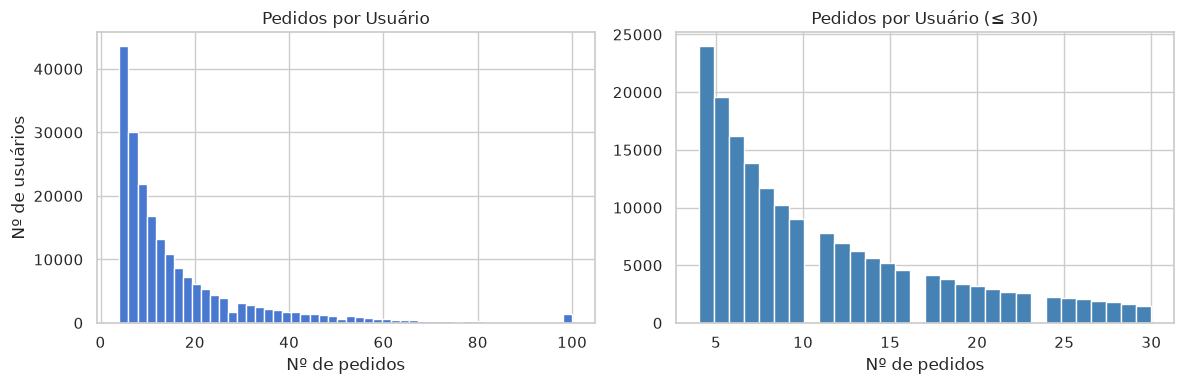

Usuários com ≥ 5 pedidos (filtro aplicado): 88.4% (182,223 usuários)


In [9]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(orders_per_user, bins=50, edgecolor="white")
axes[0].set_title("Pedidos por Usuário")
axes[0].set_xlabel("Nº de pedidos")
axes[0].set_ylabel("Nº de usuários")

axes[1].hist(
    orders_per_user[orders_per_user <= 30],
    bins=30,
    edgecolor="white",
    color="steelblue",
)
axes[1].set_title("Pedidos por Usuário (≤ 30)")
axes[1].set_xlabel("Nº de pedidos")

plt.tight_layout()
plt.savefig("data/eda_orders_per_user.png", dpi=100, bbox_inches="tight")
plt.show()

pct_5plus = (orders_per_user >= 5).mean()
print(
    f"Usuários com ≥ 5 pedidos (filtro aplicado): {pct_5plus:.1%} ({(orders_per_user >= 5).sum():,} usuários)"
)

## 5. Distribuição do Tamanho dos Pedidos (Basket Size)

In [10]:
basket_size = prior.groupby("order_id")["product_id"].count()
print(basket_size.describe())

count    3.214874e+06
mean     1.008888e+01
std      7.525398e+00
min      1.000000e+00
25%      5.000000e+00
50%      8.000000e+00
75%      1.400000e+01
max      1.450000e+02
Name: product_id, dtype: float64


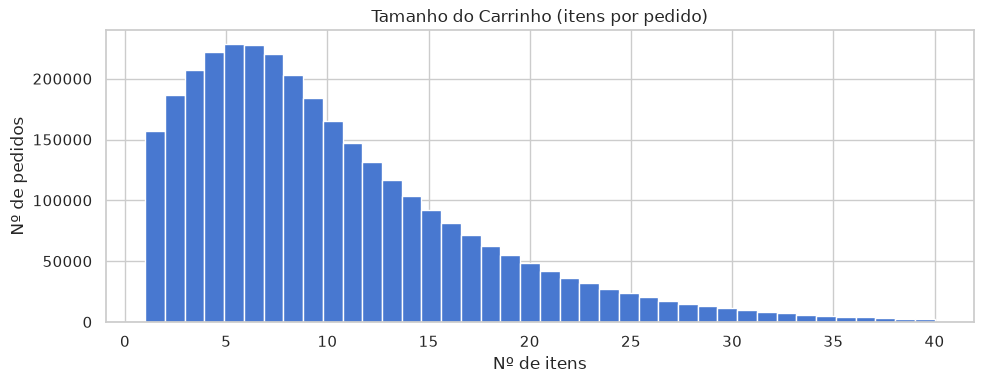

In [11]:
fig, ax = plt.subplots(figsize=(10, 4))
ax.hist(basket_size[basket_size <= 40], bins=40, edgecolor="white")
ax.set_title("Tamanho do Carrinho (itens por pedido)")
ax.set_xlabel("Nº de itens")
ax.set_ylabel("Nº de pedidos")
plt.tight_layout()
plt.savefig("data/eda_basket_size.png", dpi=100, bbox_inches="tight")
plt.show()

## 6. Taxa de Recompra (Reorder Rate)

In [12]:
overall_reorder_rate = prior["reordered"].mean()
print(f"Taxa de recompra global: {overall_reorder_rate:.2%}")
print("Implicação: ~60% das interações são recompras — sinal forte para o modelo")

Taxa de recompra global: 58.97%
Implicação: ~60% das interações são recompras — sinal forte para o modelo


In [13]:
# Reorder rate por produto (top 20 mais recomprados)
product_reorder = (
    prior.groupby("product_id")
    .agg(total=("reordered", "count"), reorders=("reordered", "sum"))
    .assign(reorder_rate=lambda x: x["reorders"] / x["total"])
)
print("Reorder rate por produto:")
print(product_reorder["reorder_rate"].describe())

Reorder rate por produto:
count    49677.000000
mean         0.366461
std          0.208103
min          0.000000
25%          0.208075
50%          0.376623
75%          0.529307
max          0.941176
Name: reorder_rate, dtype: float64


## 7. Popularidade de Produtos

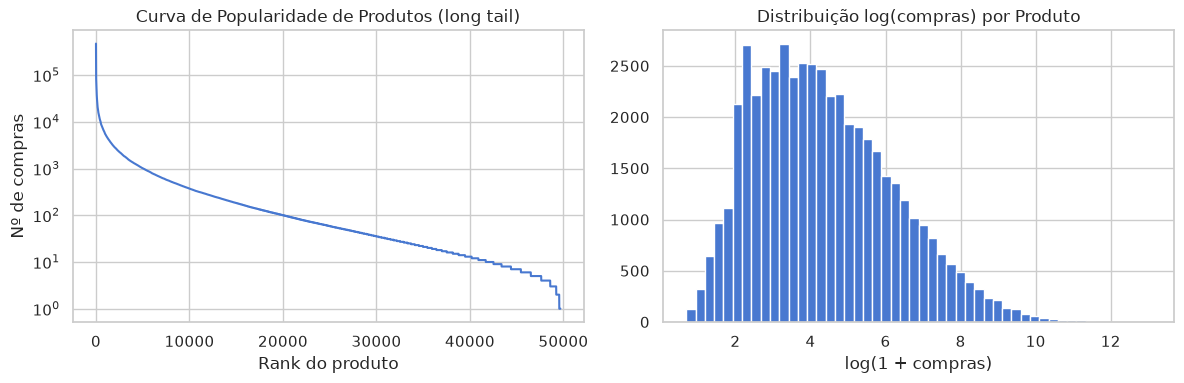

Produtos com ≥ 5 compras (filtro aplicado): 95.9% (47,618 produtos)
Top 10% produtos concentram 81.4% das interações (popularity bias)


In [14]:
product_counts = prior["product_id"].value_counts()

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(range(len(product_counts)), product_counts.values)
axes[0].set_title("Curva de Popularidade de Produtos (long tail)")
axes[0].set_xlabel("Rank do produto")
axes[0].set_ylabel("Nº de compras")
axes[0].set_yscale("log")

axes[1].hist(np.log1p(product_counts.values), bins=50, edgecolor="white")
axes[1].set_title("Distribuição log(compras) por Produto")
axes[1].set_xlabel("log(1 + compras)")

plt.tight_layout()
plt.savefig("data/eda_product_popularity.png", dpi=100, bbox_inches="tight")
plt.show()

pct_5plus_items = (product_counts >= 5).mean()
print(
    f"Produtos com ≥ 5 compras (filtro aplicado): {pct_5plus_items:.1%} ({(product_counts >= 5).sum():,} produtos)"
)

top10_pct = (
    product_counts.head(int(len(product_counts) * 0.1)).sum() / product_counts.sum()
)
print(f"Top 10% produtos concentram {top10_pct:.1%} das interações (popularity bias)")

## 8. Padrões Temporais

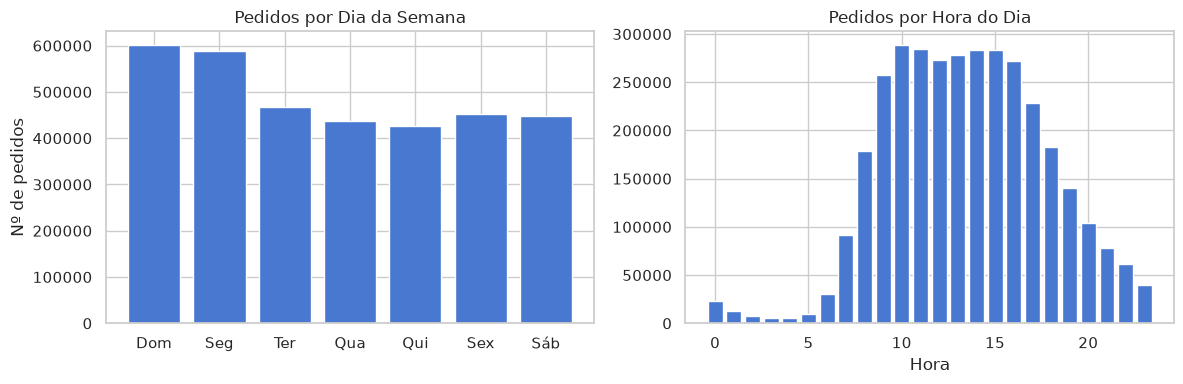

In [15]:
dow_map = {0: "Dom", 1: "Seg", 2: "Ter", 3: "Qua", 4: "Qui", 5: "Sex", 6: "Sáb"}

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

dow_counts = orders["order_dow"].value_counts().sort_index()
axes[0].bar([dow_map[i] for i in dow_counts.index], dow_counts.values)
axes[0].set_title("Pedidos por Dia da Semana")
axes[0].set_ylabel("Nº de pedidos")

hour_counts = orders["order_hour_of_day"].value_counts().sort_index()
axes[1].bar(hour_counts.index, hour_counts.values)
axes[1].set_title("Pedidos por Hora do Dia")
axes[1].set_xlabel("Hora")

plt.tight_layout()
plt.savefig("data/eda_temporal_patterns.png", dpi=100, bbox_inches="tight")
plt.show()

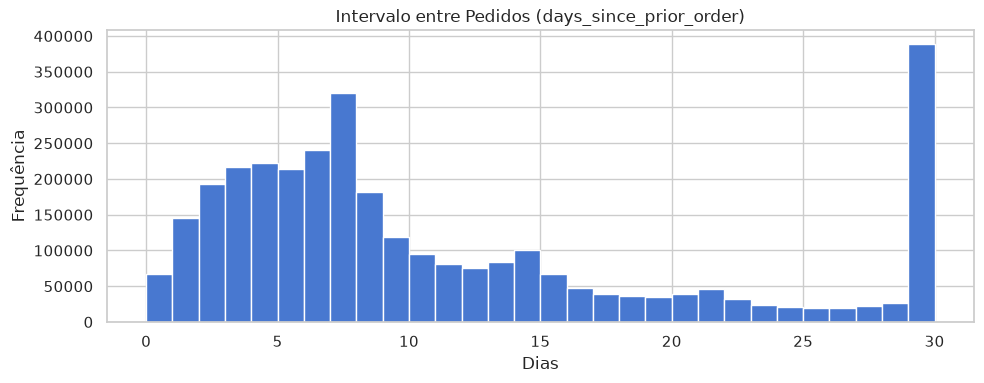

count    3.214874e+06
mean     1.111484e+01
std      9.206737e+00
min      0.000000e+00
25%      4.000000e+00
50%      7.000000e+00
75%      1.500000e+01
max      3.000000e+01
Name: days_since_prior_order, dtype: float64

Intervalos ≤ 30 dias: 100.0% (escopo de inferência definido)


In [16]:
# Intervalo entre pedidos
days_between = orders["days_since_prior_order"].dropna()

fig, ax = plt.subplots(figsize=(10, 4))
ax.hist(days_between, bins=30, edgecolor="white")
ax.set_title("Intervalo entre Pedidos (days_since_prior_order)")
ax.set_xlabel("Dias")
ax.set_ylabel("Frequência")
plt.tight_layout()
plt.savefig("data/eda_days_between_orders.png", dpi=100, bbox_inches="tight")
plt.show()

print(days_between.describe())
pct_30days = (days_between <= 30).mean()
print(f"\nIntervalos ≤ 30 dias: {pct_30days:.1%} (escopo de inferência definido)")

## 9. Departamentos e Corredores

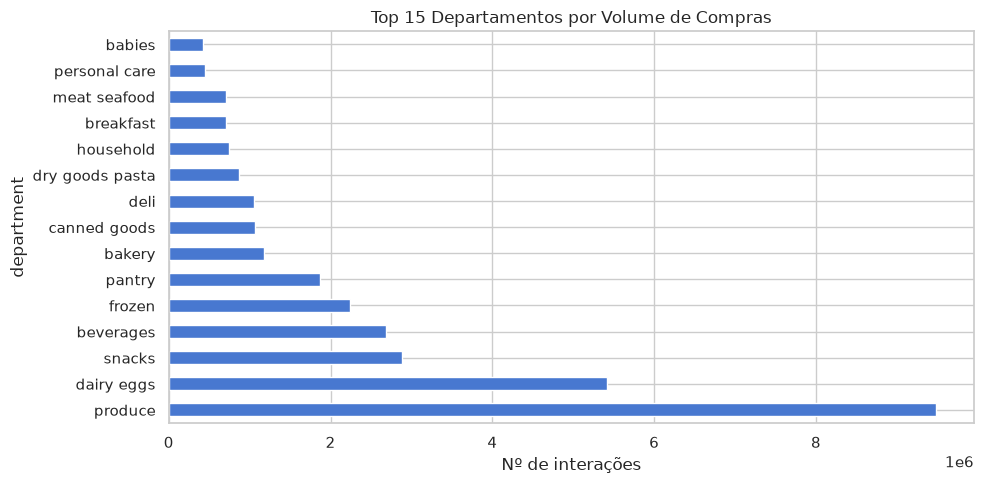

In [17]:
products_enriched = products.merge(aisles, on="aisle_id").merge(
    departments, on="department_id"
)

prior_enriched = prior.merge(
    products_enriched[["product_id", "department"]], on="product_id"
)
dept_counts = prior_enriched["department"].value_counts().head(15)

fig, ax = plt.subplots(figsize=(10, 5))
dept_counts.plot(kind="barh", ax=ax)
ax.set_title("Top 15 Departamentos por Volume de Compras")
ax.set_xlabel("Nº de interações")
plt.tight_layout()
plt.savefig("data/eda_departments.png", dpi=100, bbox_inches="tight")
plt.show()

## 10. Análise de Esparsidade e Viabilidade do Modelo

In [18]:
# Interações por usuário (prior)
prior_with_user = prior.merge(orders[["order_id", "user_id"]], on="order_id")
ui_interactions = prior_with_user.groupby("user_id")["product_id"].nunique()

print("Produtos únicos comprados por usuário:")
print(ui_interactions.describe())
print(f"\nUsuários com ≥ 5 produtos distintos: {(ui_interactions >= 5).mean():.1%}")

Produtos únicos comprados por usuário:
count    206209.000000
mean         64.536238
std          56.592339
min           1.000000
25%          25.000000
50%          48.000000
75%          86.000000
max         726.000000
Name: product_id, dtype: float64

Usuários com ≥ 5 produtos distintos: 98.4%


In [19]:
# Produtos no ground truth (train set) — o que o modelo precisa acertar
train_with_user = train.merge(orders[["order_id", "user_id"]], on="order_id")
items_per_user_test = train_with_user.groupby("user_id")["product_id"].count()

print("Itens no último pedido (ground truth para avaliação):")
print(items_per_user_test.describe())
print(f"\nMediana de itens no último pedido: {items_per_user_test.median():.0f}")
print(
    f"Com K=20, Recall máximo teórico médio: {min(20, items_per_user_test.median()) / items_per_user_test.median():.1%}"
)

Itens no último pedido (ground truth para avaliação):
count    131209.000000
mean         10.552759
std           7.932847
min           1.000000
25%           5.000000
50%           9.000000
75%          14.000000
max          80.000000
Name: product_id, dtype: float64

Mediana de itens no último pedido: 9
Com K=20, Recall máximo teórico médio: 100.0%


## 11. Resumo e Implicações para o Pipeline

In [20]:
print("=" * 55)
print("RESUMO EDA — IMPLICAÇÕES PARA O SISTEMA DE RECOMENDAÇÃO")
print("=" * 55)

last_order_days = (
    orders.sort_values("order_number")
    .groupby("user_id")["days_since_prior_order"]
    .last()
)
n_active = (last_order_days <= 30).sum()

print(f"""
Volume:
  {n_users:,} usuários | {n_products:,} produtos | {n_interact:,} interações
  Esparsidade: {1 - density:.4%} → feedback implícito, BCELoss com pos_weight

Filtros (preprocess stage):
  Usuários ≥ 5 pedidos:    {(orders_per_user >= 5).sum():,} usuários ({pct_5plus:.1%})
  Produtos ≥ 5 compras:    {(product_counts >= 5).sum():,} produtos ({pct_5plus_items:.1%})
  Usuários ativos (≤30d):  {n_active:,} usuários (escopo de inferência)

Sinais relevantes para features:
  Taxa de recompra global: {overall_reorder_rate:.1%} → feature reordered é sinal forte
  Popularity bias:         top 10% produtos = {top10_pct:.1%} das interações
  Pico de compras:         Dom/Seg, 10h-16h → features order_dow e order_hour

Ground truth (test set):
  Mediana de itens por usuário no último pedido: {items_per_user_test.median():.0f}
  → K=20 cobre adequadamente a maioria dos casos
""")

RESUMO EDA — IMPLICAÇÕES PARA O SISTEMA DE RECOMENDAÇÃO



Volume:
  206,209 usuários | 49,688 produtos | 32,434,489 interações
  Esparsidade: 99.6834% → feedback implícito, BCELoss com pos_weight

Filtros (preprocess stage):
  Usuários ≥ 5 pedidos:    182,223 usuários (88.4%)
  Produtos ≥ 5 compras:    47,618 produtos (95.9%)
  Usuários ativos (≤30d):  206,209 usuários (escopo de inferência)

Sinais relevantes para features:
  Taxa de recompra global: 59.0% → feature reordered é sinal forte
  Popularity bias:         top 10% produtos = 81.4% das interações
  Pico de compras:         Dom/Seg, 10h-16h → features order_dow e order_hour

Ground truth (test set):
  Mediana de itens por usuário no último pedido: 9
  → K=20 cobre adequadamente a maioria dos casos

